Terminologi

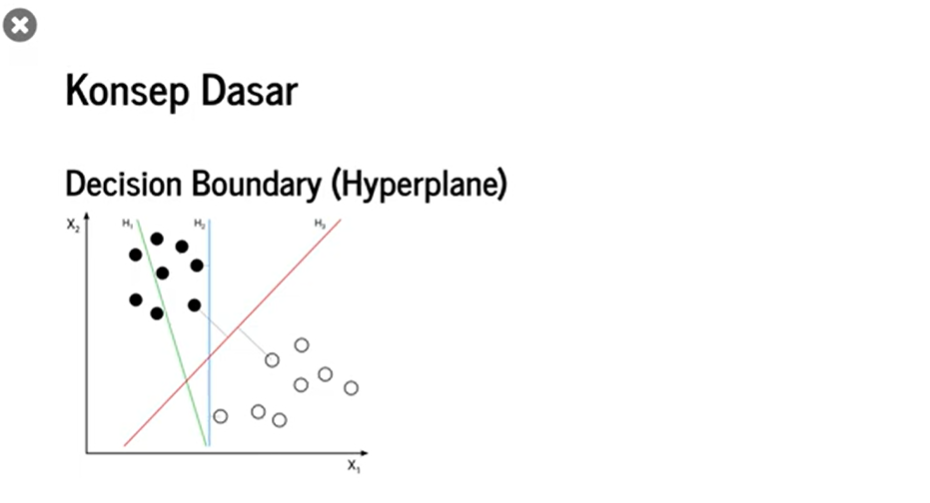

* Kalau featurenya 1:decision boundery atau pemisal antar kelasnya akan berupa titik atau treshold
* Kalau featurenya 2 : decision boundery atau pemisah antar kelasnya akan berupa garis atau linear
* Kalau featurenya 3 : decision boundery atau pemisah antar kelasnya akan bidang datar atau disebut plane
* Kalau featurenya 4 atau lebih : decision boundery atau pemisah antar kelasnya akan berupa bidang multi dimensi yang disebut hyperplane


Bagaimana menentukan hyperplane paling baik?

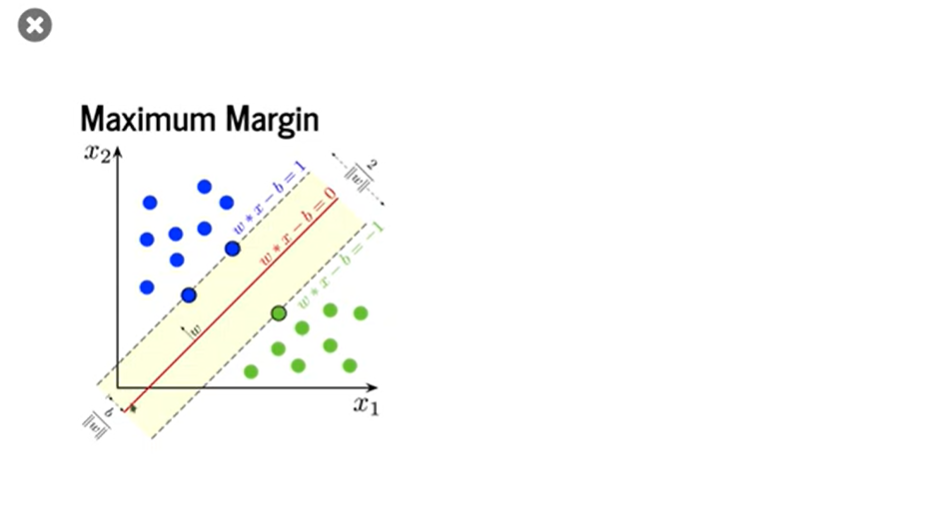

margin adalah jarak terdekat antara decision boundery dengan titik data yang paling dekat. Arean yang berwarna kuning adalah margin

Untuk data poin yang paling dekat tersebut di sebut support vector

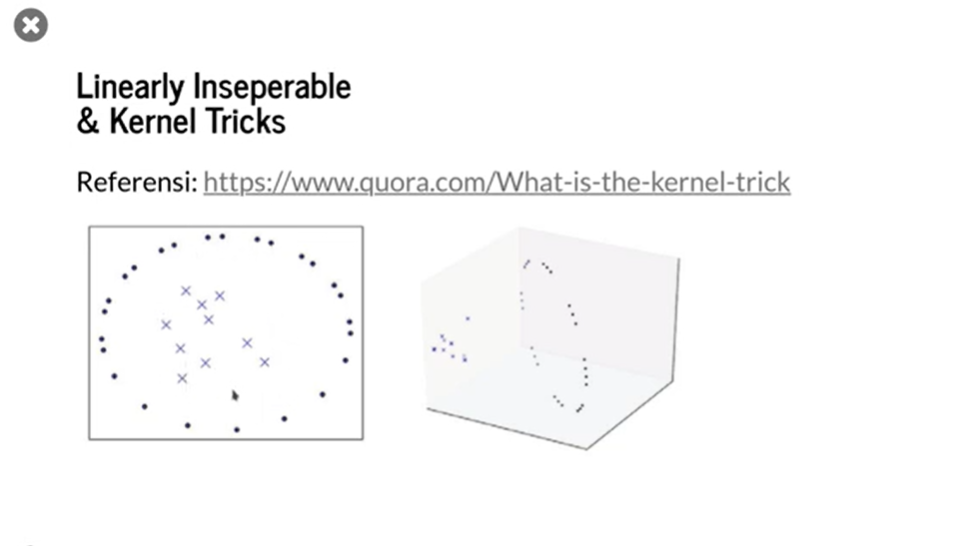

In [ ]:
!rm -rf '/content/drive/MyDrive/Asah - Dicoding/Praktikum/openml'


In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

# Muat dataset MNIST dari Keras (otomatis di-cache)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Ubah bentuk agar sama seperti format OpenML (784 fitur)
X = np.concatenate([X_train, X_test]).reshape(-1, 28*28)
y = np.concatenate([y_train, y_test])

print("Data shape:", X.shape)
print("Label shape:", y.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data shape: (70000, 784)
Label shape: (70000,)


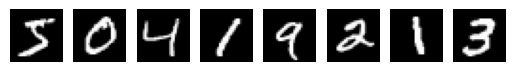

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as compile

pos = 1
for data in X[:8]:
  plt.subplot( 1, 8, pos)
  plt.imshow(data.reshape((28, 28)),
             cmap='gray')
  plt.axis('off') # Added to turn off axis labels for cleaner display
  pos += 1 # Increment pos for the next subplot
plt.show()

In [ ]:
y[:8]

array([5, 0, 4, 1, 9, 2, 1, 3], dtype=uint8)

In [ ]:
# X_train = X[:60000]
# y_train = y[:60000]
# X_test = X[60000:]
# y_test = y[60000:]

X_train = X[:1000]
y_train = y[:1000]
X_test = X[69000:]
y_test = y[69000:]

In [ ]:
from sklearn.svm import SVC

model = SVC( kernel='poly')
model.fit(X_train, y_train)

SVC(kernel='poly')

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       102
           1       0.83      0.97      0.90       119
           2       0.90      0.82      0.86        99
           3       0.97      0.82      0.89       102
           4       0.89      0.92      0.90        92
           5       0.84      0.86      0.85        85
           6       0.96      0.92      0.94       102
           7       0.90      0.95      0.92       115
           8       0.91      0.90      0.91        94
           9       0.92      0.87      0.89        90

    accuracy                           0.90      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000




Confusion Matrix:
 [[ 99   0   0   0   0   1   1   0   1   0]
 [  0 117   0   0   0   0   0   0   2   0]
 [  3   4  80   3   0   1   3   1   4   0]
 [  1   0   8  82   0   5   0   1   4   1]
 [  0   0   0   0  83   0   0   0   2   7]
 [  2   2   1   2   1  73   3   0   0   1]
 [  0   0   2   0   1   5  93   0   1   0]
 [  0   0   8   0   0   0   0 107   0   0]
 [  0   1   3   3   1   4   0   1  80   1]
 [  0   0   0   0   7   1   0   6   1  75]]


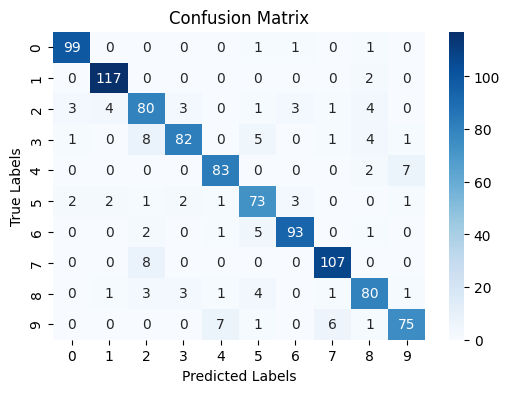

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Jika kamu tahu nama kelas (opsional, agar lebih informatif)
# misalnya: class_names = ['Negatif', 'Positif']
# maka tambahkan ke heatmap di bagian "xticklabels" dan "yticklabels"

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

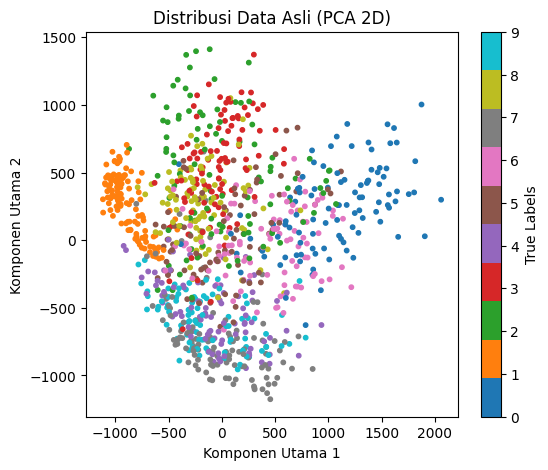

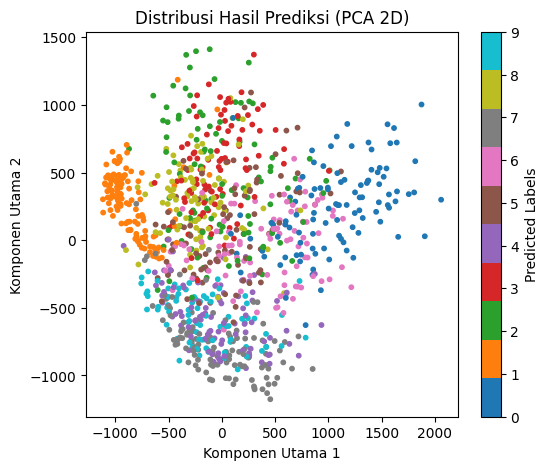

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Misal kamu sudah punya:
# X_train, X_test, y_train, y_test, y_pred

# --- 1. Reduksi dimensi jadi 2D untuk visualisasi ---
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# --- 2. Plot berdasarkan label asli ---
plt.figure(figsize=(6,5))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            c=y_test.astype(int), cmap='tab10', s=10)
plt.title('Distribusi Data Asli (PCA 2D)')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.colorbar(label='True Labels')
plt.show()

# --- 3. Plot berdasarkan label prediksi ---
plt.figure(figsize=(6,5))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            c=y_pred.astype(int), cmap='tab10', s=10)
plt.title('Distribusi Hasil Prediksi (PCA 2D)')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.colorbar(label='Predicted Labels')
plt.show()


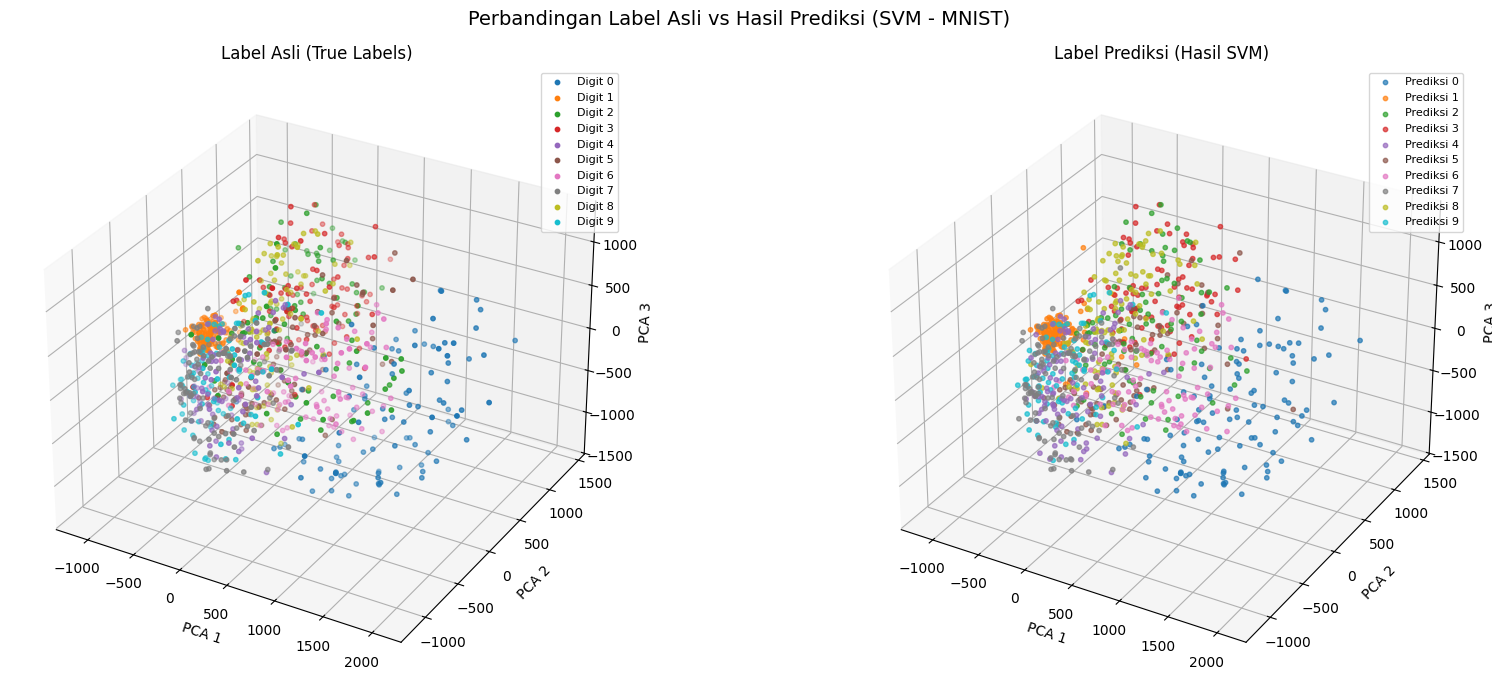

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import numpy as np

# Pastikan kamu sudah punya:
# X_test, y_test, y_pred

# --- 1. Reduksi dimensi ke 3 komponen PCA ---
pca = PCA(n_components=3)
X_test_pca = pca.fit_transform(X_test)

# --- 2. Buat figure 3D ---
fig = plt.figure(figsize=(18, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # warna untuk 10 digit

# ----------------------------
# Plot 1: Label Asli
# ----------------------------
ax1 = fig.add_subplot(121, projection='3d')
for i in np.unique(y_test):
    subset = X_test_pca[y_test == i]
    ax1.scatter(subset[:, 0], subset[:, 1], subset[:, 2],
                color=colors[i], label=f"Digit {i}", s=10)
ax1.set_title("Label Asli (True Labels)", fontsize=12)
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")
ax1.set_zlabel("PCA 3")
ax1.legend(loc='upper right', fontsize=8)

# ----------------------------
# Plot 2: Label Prediksi
# ----------------------------
ax2 = fig.add_subplot(122, projection='3d')
for i in np.unique(y_pred):
    subset = X_test_pca[y_pred == i]
    ax2.scatter(subset[:, 0], subset[:, 1], subset[:, 2],
                color=colors[i], label=f"Prediksi {i}", s=10, alpha=0.7)
ax2.set_title("Label Prediksi (Hasil SVM)", fontsize=12)
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_zlabel("PCA 3")
ax2.legend(loc='upper right', fontsize=8)

# ----------------------------
# Judul Utama
# ----------------------------
plt.suptitle("Perbandingan Label Asli vs Hasil Prediksi (SVM - MNIST)", fontsize=14)
plt.tight_layout()
plt.show()

# hyperparameter Tunning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Parameter grid untuk SVM
parameters = {
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'C': [0.5, 1, 10, 100],
    'gamma': ['scale', 1, 0.1, 0.01, 0.001]
}

# Membuat objek GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(random_state=0),
    param_grid=parameters,
    n_jobs=6,
    verbose=1,
    scoring='accuracy'
)

# Melatih model dengan data pelatihan
grid_search.fit(X_train, y_train)

In [ ]:
print (f'Best score: {grid_search.best_score_}')

# Access best_params_ from the grid_search object
best_params = grid_search.best_params_
print (f'Best parameters: {best_params}')
for param in parameters:
  print (f'\t{param}: {best_params[param]}')

In [ ]:
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))